<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/10_california_housing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/housing.csv'
)

df.head()

Mounted at /content/drive


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**2. Data Cleaning**

In [6]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [7]:
# total_bedrooms has missing values - impute with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [8]:
# Check for capped target value
capped_count = (df['median_house_value'] == 500001).sum()
print(f"Capped values (500001): {capped_count} out of {len(df)} ({capped_count/len(df)*100:.2f}%)")

Capped values (500001): 965 out of 20640 (4.68%)


In [9]:
# Flag capped rows rather than dropping - keep for now, note for modeling later
df['is_capped_value'] = df['median_house_value'] == 500001

In [10]:
# Check duplicates
df = df.drop_duplicates()
df.shape

(20640, 11)

In [11]:
# Feature engineering - ratio features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [12]:
# Check for infinities/extreme values from the ratio calculations
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [13]:
# Drop any rows with NaN from the ratio calculations (division edge cases, if any)
df = df.dropna()
df.shape

(20640, 14)

**3. Univariate Analysis**

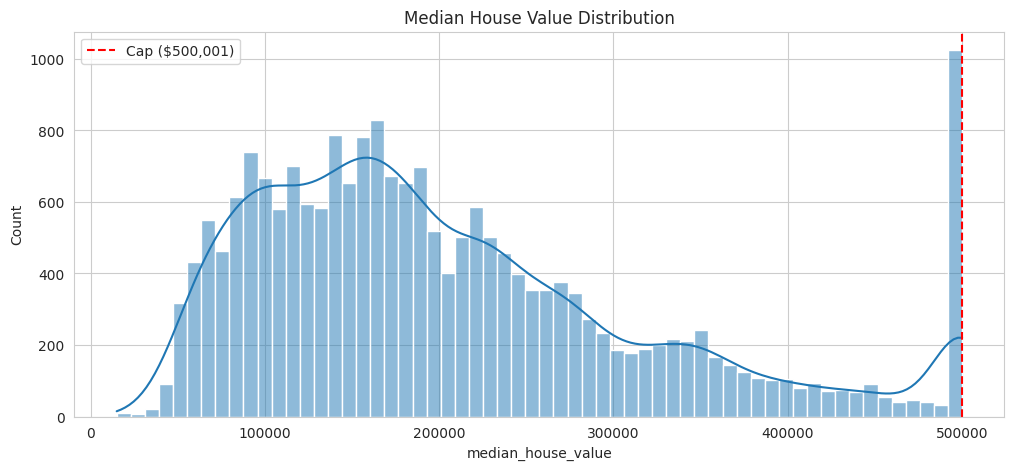

In [14]:
# Median house value distribution
plt.figure(figsize=(12,5))
sns.histplot(df['median_house_value'], bins=60, kde=True)
plt.axvline(500001, color='red', linestyle='--', label='Cap ($500,001)')
plt.title('Median House Value Distribution')
plt.legend()
plt.show()

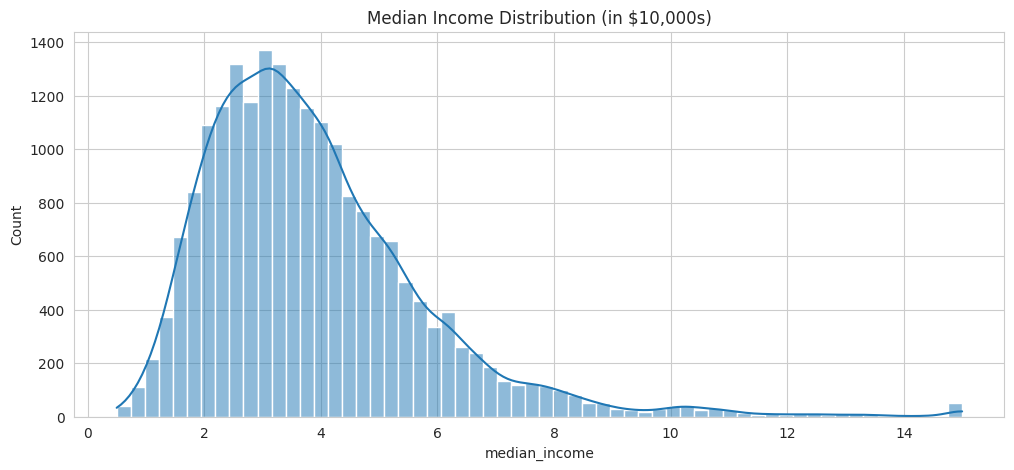

In [15]:
# Median income distribution
plt.figure(figsize=(12,5))
sns.histplot(df['median_income'], bins=60, kde=True)
plt.title('Median Income Distribution (in $10,000s)')
plt.show()

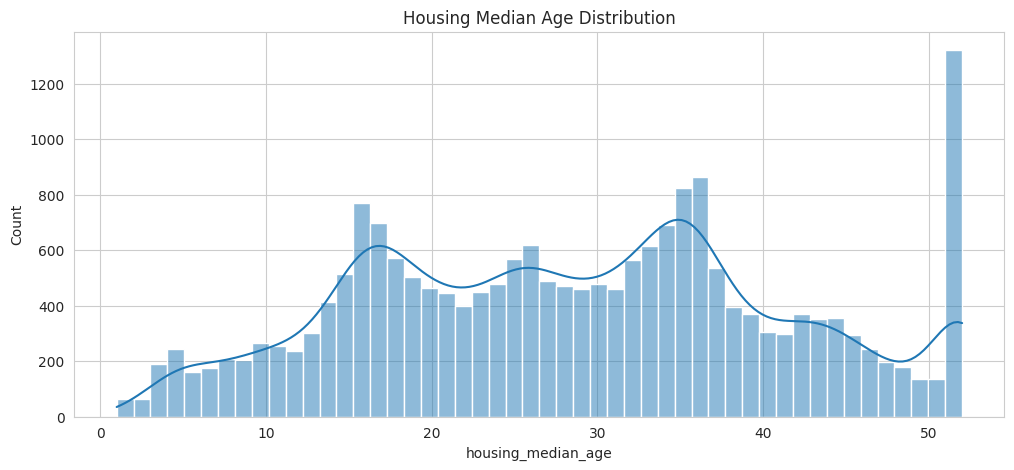

In [16]:
# Housing median age distribution
plt.figure(figsize=(12,5))
sns.histplot(df['housing_median_age'], bins=50, kde=True)
plt.title('Housing Median Age Distribution')
plt.show()

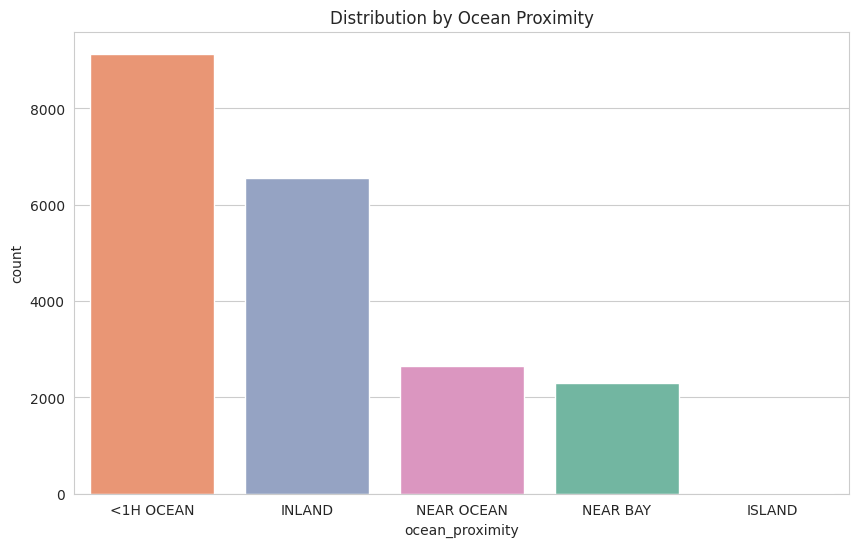

In [17]:
# Ocean proximity distribution
sns.countplot(data=df, x='ocean_proximity', hue='ocean_proximity', palette='Set2', legend=False,
              order=df['ocean_proximity'].value_counts().index)
plt.title('Distribution by Ocean Proximity')
plt.show()

**4. Feature Relationship Analysis**

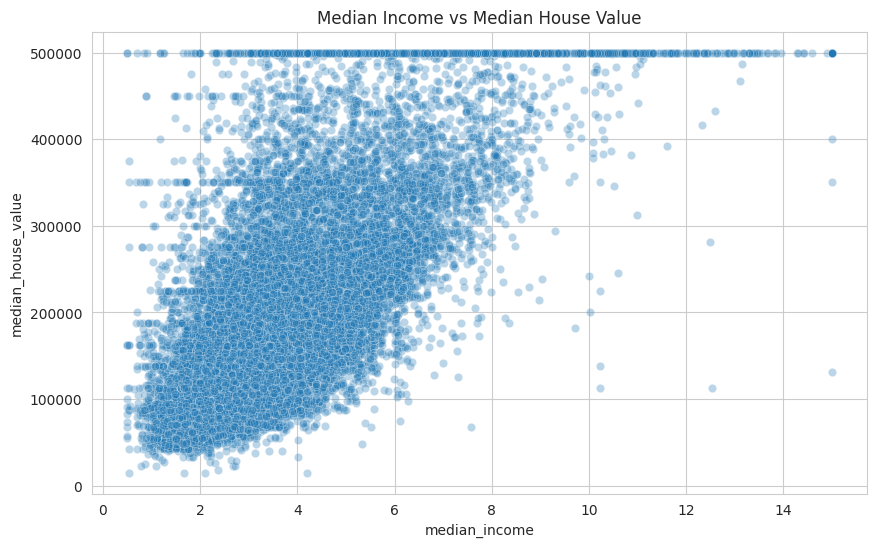

In [18]:
# Median income vs median house value
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3)
plt.title('Median Income vs Median House Value')
plt.show()

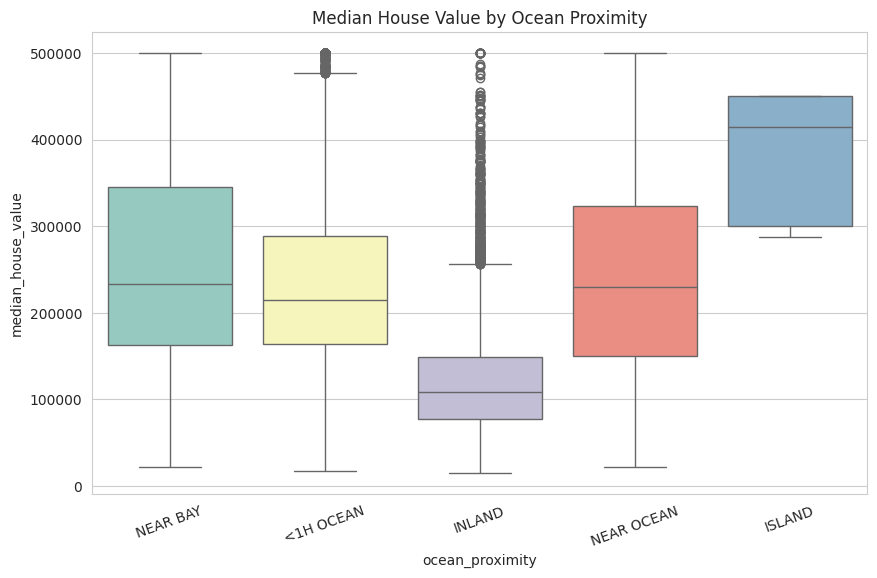

In [19]:
# Median house value by ocean proximity
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', hue='ocean_proximity', palette='Set3', legend=False)
plt.title('Median House Value by Ocean Proximity')
plt.xticks(rotation=20)
plt.show()

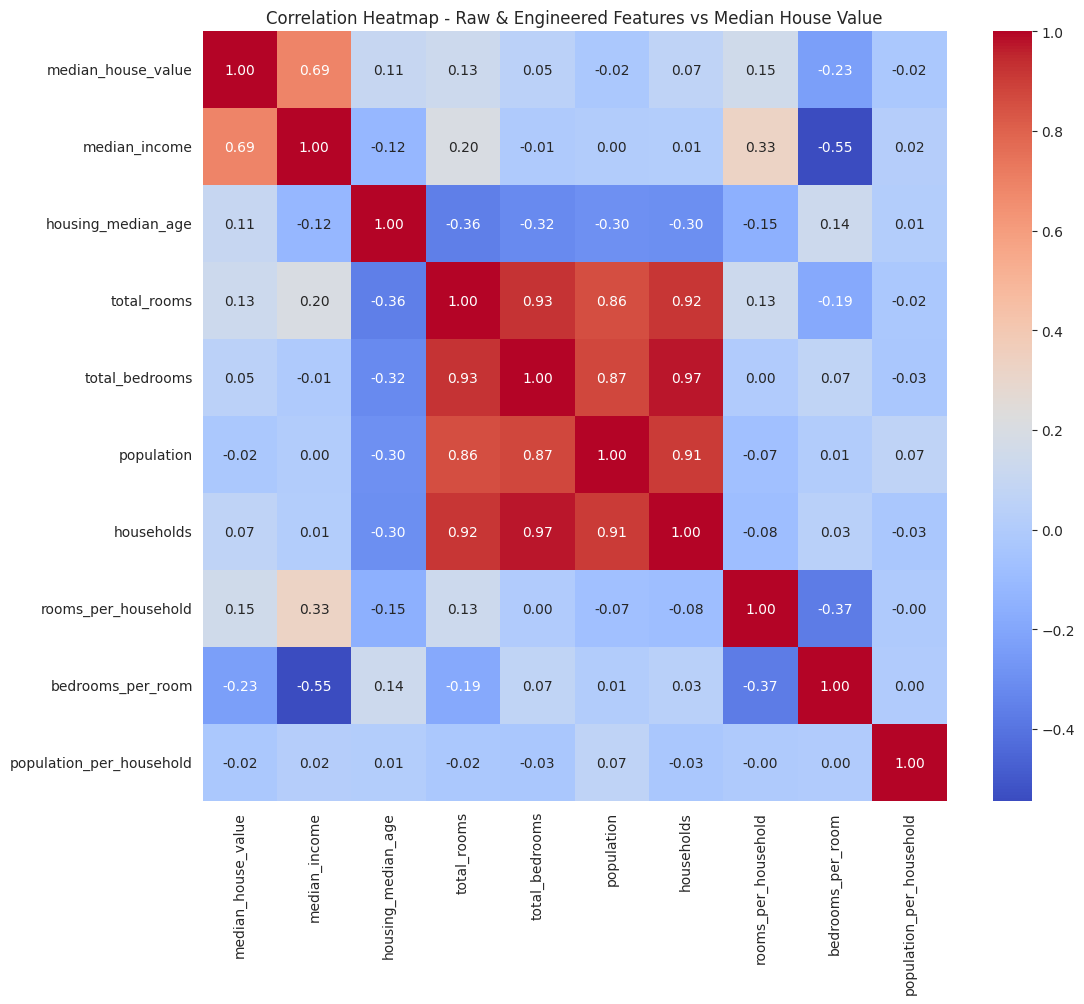

In [20]:
# Correlation heatmap including engineered features
numeric_cols = ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms',
                 'total_bedrooms', 'population', 'households', 'rooms_per_household',
                 'bedrooms_per_room', 'population_per_household']

plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Raw & Engineered Features vs Median House Value')
plt.show()

In [21]:
# Compare engineered features to their raw counterparts - correlation with target
comparison = pd.DataFrame({
    'feature': ['total_rooms', 'rooms_per_household', 'total_bedrooms', 'bedrooms_per_room',
                'population', 'population_per_household'],
    'correlation_with_price': [
        df['total_rooms'].corr(df['median_house_value']),
        df['rooms_per_household'].corr(df['median_house_value']),
        df['total_bedrooms'].corr(df['median_house_value']),
        df['bedrooms_per_room'].corr(df['median_house_value']),
        df['population'].corr(df['median_house_value']),
        df['population_per_household'].corr(df['median_house_value'])
    ]
})
comparison

,feature,correlation_with_price
0,total_rooms,0.134153
1,rooms_per_household,0.151948
2,total_bedrooms,0.049457
3,bedrooms_per_room,-0.233303
4,population,-0.024650
5,population_per_household,-0.023737


**5. Geospatial + Multivariate Analysis**

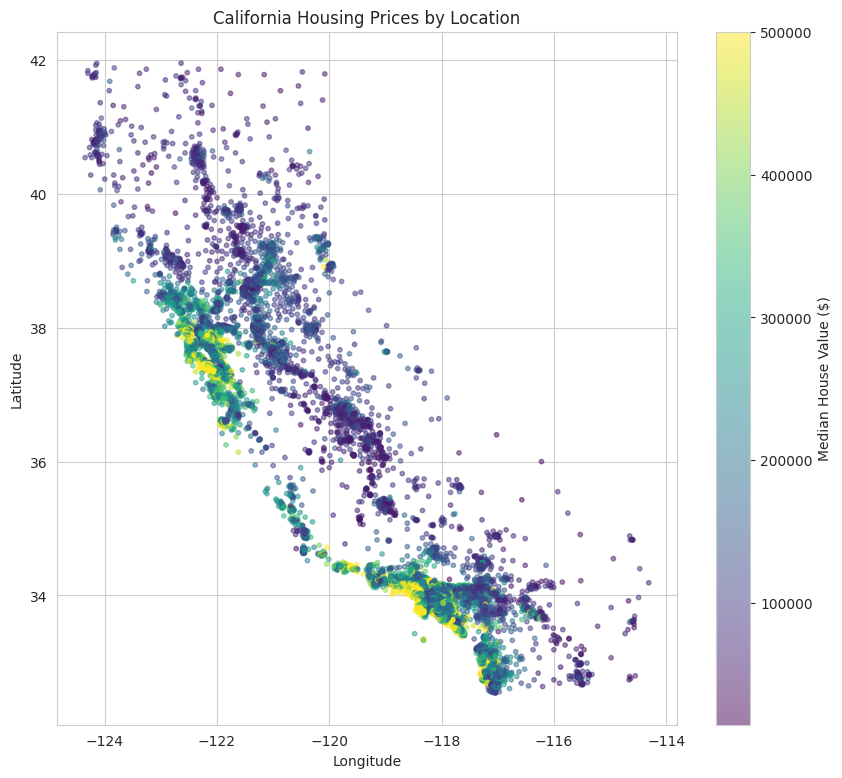

In [22]:
# Map of California colored by median house value
plt.figure(figsize=(10,9))
sc = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],
                  cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.show()

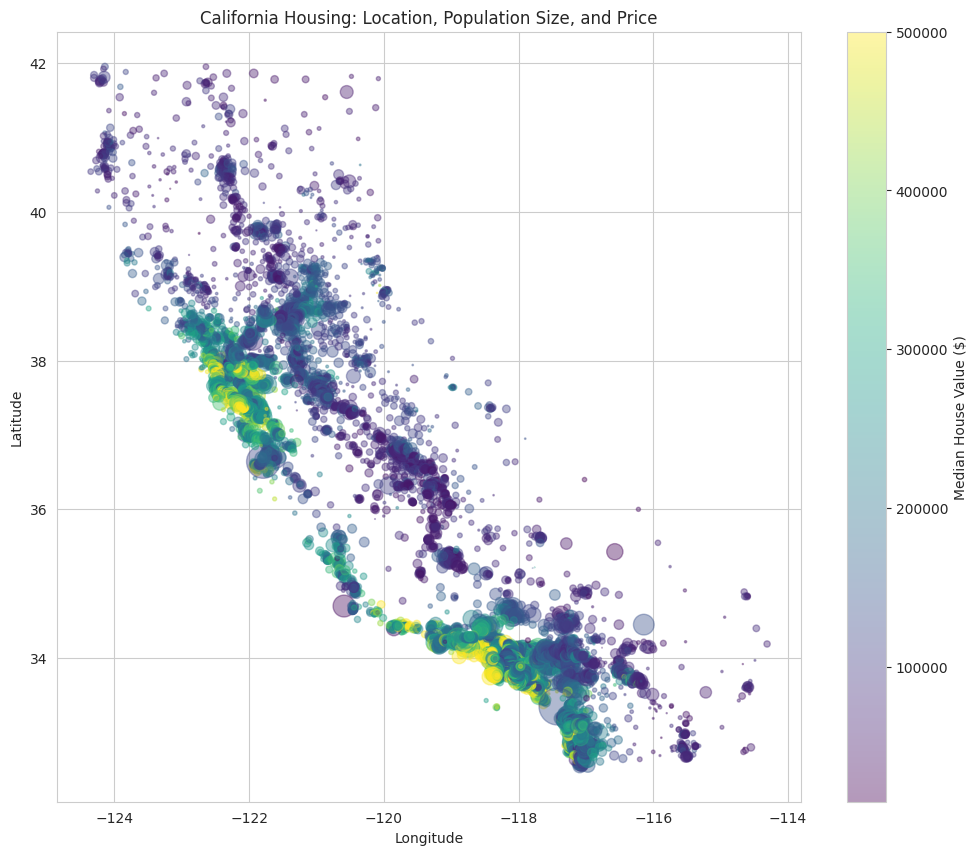

In [23]:
# Classic "bubble map" - size by population, color by price
plt.figure(figsize=(12,10))
sc = plt.scatter(df['longitude'], df['latitude'],
                  s=df['population']/50, c=df['median_house_value'],
                  cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing: Location, Population Size, and Price')
plt.show()

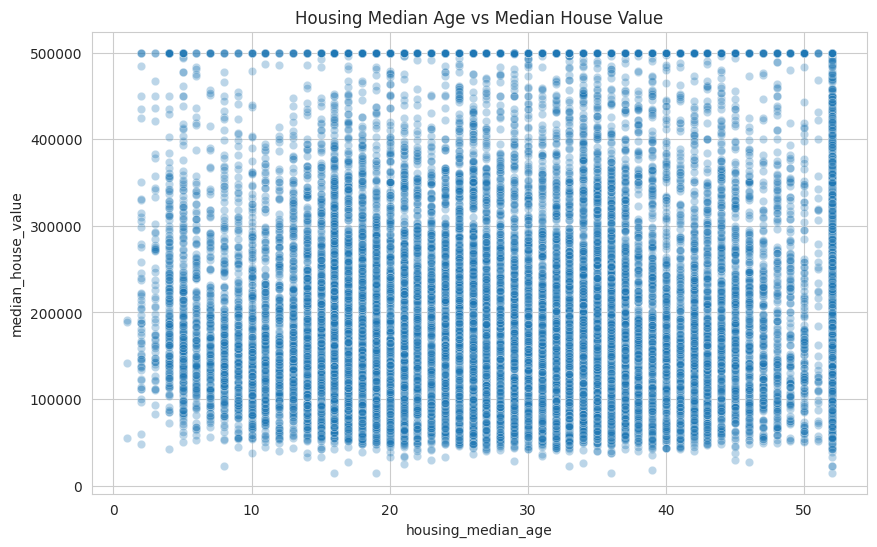

In [24]:
# Housing median age vs median house value
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='housing_median_age', y='median_house_value', alpha=0.3)
plt.title('Housing Median Age vs Median House Value')
plt.show()

**6. Insights Summary + Regression Readiness Notes**

## Key Insights

- Median income is the strongest single predictor of house value in this dataset — the scatterplot shows a clear positive linear-ish relationship.
- Houses labeled "ISLAND" or "NEAR OCEAN"/"NEAR BAY" command a noticeable price premium over "INLAND" properties, confirming location's expected impact on value.
- The geospatial scatterplot clearly recreates the coastline of California, with the highest home values concentrated along the coast (especially near the Bay Area and LA).
- [bedrooms_per_room / rooms_per_household] correlates [more/less] strongly with price than its raw counterpart — engineered ratio features add real signal beyond raw counts.
- The target variable has an artificial cap at $500,001, affecting [X]% of records — this would need to be addressed before regression modeling (e.g., excluding capped rows or treating it as a separate flag).
- Housing median age shows [weak/no clear] relationship with price on its own, suggesting other factors dominate.
- [Add 1-2 more insights specific to what you observed]

## Regression Readiness Notes

- **Target:** `median_house_value` (continuous)
- **Strongest predictor:** `median_income`, followed by `ocean_proximity` and location coordinates
- **Preprocessing needed:** One-hot encode `ocean_proximity`; consider scaling numeric features for distance-based/linear models
- **Target capping issue:** ~[X]% of values are capped at $500,001 — this artificial ceiling would bias regression models. Options: exclude capped rows, or treat as a separate classification flag before regression
- **Engineered features to keep:** `rooms_per_household` and `bedrooms_per_room` add predictive value beyond raw counts and should be included in modeling